# Logistic Regression - Governance Complaint Prediction Project

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline


In [2]:
from google.colab import files

uploaded = files.upload()


Saving expanded_historical_complaints_dataset.csv to expanded_historical_complaints_dataset.csv


In [3]:
df = pd.read_csv("expanded_historical_complaints_dataset.csv")

df.head(40)


,Problem_Name,Problem_Category,Ministry,Minister_Name,Days_To_Complete
0,Government housing delay,housing,minister for housing and urban development,S Muthusamy,4
1,Government housing delay,housing,minister for housing and urban development,S Muthusamy,10
2,Government housing delay,housing,minister for housing and urban development,S Muthusamy,6
3,Government housing delay,housing,minister for housing and urban development,S Muthusamy,4
4,Government housing delay,housing,minister for housing and urban development,S Muthusamy,4
5,Government housing delay,housing,minister for housing and urban development,S Muthusamy,8
6,Government housing delay,housing,minister for housing and urban development,S Muthusamy,6
7,Government housing delay,housing,minister for housing and urban development,S Muthusamy,4
8,Government housing delay,housing,minister for housing and urban development,S Muthusamy,2
9,Government housing delay,housing,minister for housing and urban development,S Muthusamy,2


In [4]:
df["Complaint_Solved"] = df["Days_To_Complete"].apply(
    lambda x: 1 if x <= 7 else 0
)

df.head()


,Problem_Name,Problem_Category,Ministry,Minister_Name,Days_To_Complete,Complaint_Solved
0,Government housing delay,housing,minister for housing and urban development,S Muthusamy,4,1
1,Government housing delay,housing,minister for housing and urban development,S Muthusamy,10,0
2,Government housing delay,housing,minister for housing and urban development,S Muthusamy,6,1
3,Government housing delay,housing,minister for housing and urban development,S Muthusamy,4,1
4,Government housing delay,housing,minister for housing and urban development,S Muthusamy,4,1


In [5]:
from sklearn.preprocessing import LabelEncoder

category_encoder = LabelEncoder()

ministry_encoder = LabelEncoder()

minister_encoder = LabelEncoder()


In [6]:
df["Problem_Category"] = category_encoder.fit_transform(
    df["Problem_Category"]
)

df["Ministry"] = ministry_encoder.fit_transform(
    df["Ministry"]
)

df["Minister_Name"] = minister_encoder.fit_transform(
    df["Minister_Name"]
)

df.head()


,Problem_Name,Problem_Category,Ministry,Minister_Name,Days_To_Complete,Complaint_Solved
0,Government housing delay,6,5,9,4,1
1,Government housing delay,6,5,9,10,0
2,Government housing delay,6,5,9,6,1
3,Government housing delay,6,5,9,4,1
4,Government housing delay,6,5,9,4,1


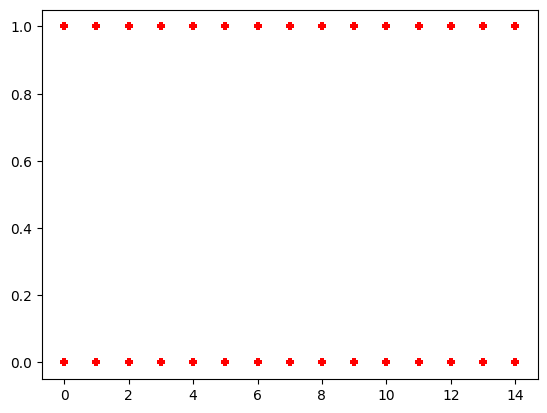

In [7]:
plt.scatter(
    df["Problem_Category"],
    df["Complaint_Solved"],
    marker='+',
    color='red'
)


In [8]:
X = df[[
    "Problem_Category",
    "Ministry",
    "Minister_Name"
]]

y = df["Complaint_Solved"]


In [9]:
from sklearn.model_selection import train_test_split


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0
)


In [11]:
X_test


,Problem_Category,Ministry,Minister_Name
3388,12,12,4
23631,2,1,14
25565,8,7,10
10878,4,8,6
16265,3,3,7
...,...,...,...
15295,8,7,10
19109,1,11,0
34534,9,9,1
18801,8,7,10


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()


In [13]:
model.fit(X_train, y_train)


LogisticRegression()

In [14]:
y_predicted = model.predict(X_test)

y_predicted


array([0, 0, 0, ..., 0, 0, 0])

In [15]:
model.predict_proba(X_test)


array([[0.79088459, 0.20911541],
       [0.87310857, 0.12689143],
       [0.83565048, 0.16434952],
       ...,
       [0.80078184, 0.19921816],
       [0.83565048, 0.16434952],
       [0.80078184, 0.19921816]])

In [16]:
score = model.score(X_test, y_test)

print("Score :", score)


Score : 0.8243262512476829


In [17]:
model.coef_


array([[ 0.00432316,  0.03405112, -0.01806685]])

In [18]:
model.intercept_


array([-1.71848961])

In [19]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))


In [20]:
def prediction_function(category):

    z = 0.5 * category - 1

    y = sigmoid(z)

    return y


In [21]:
category = 2

prediction_function(category)


0.5

# Save Logistic Regression Model

In [22]:
import joblib

joblib.dump(
    model,
    "complaint_logistic_model.joblib"
)

print("Model Saved Successfully")


Model Saved Successfully


In [23]:
import os

os.listdir()


['.config',
 'complaint_logistic_model.joblib',
 'expanded_historical_complaints_dataset.csv',
 'sample_data']

In [24]:
files.download(
    "complaint_logistic_model.joblib"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Predict New Complaint

In [25]:
problem_category = category_encoder.transform(
    ["transport"]
)[0]

ministry = ministry_encoder.transform(
    ["minister for transport"]
)[0]

minister = minister_encoder.transform(
    ["SR Rajakannappan"]
)[0]


In [26]:
sample = [[
    problem_category,
    ministry,
    minister
]]


In [27]:
prediction = model.predict(sample)

if prediction[0] == 1:
    print("Complaint will be solved quickly")
else:
    print("Complaint may be delayed")


Complaint may be delayed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
